In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "8"

import numpy as np
from operators import operator_hex,operator_loss_hex,state_hex,state_loss_hex,gkp_squeezing

import scipy.optimize as so
import matplotlib.pyplot as plt

In [5]:
def minimize(objective, x0, bounds):
    result = so.minimize(objective, x0, method = 'L-BFGS-B', bounds = bounds)
    return result.fun,result.x

def minimize_multistart(objective, bounds, nstart=300):
    best_fun = np.inf
    best_x = None

    for _ in range(nstart):
        x0 = np.array([np.random.uniform(low, high) for low, high in bounds])
        res = so.minimize(objective,x0,method='L-BFGS-B', bounds=bounds)
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    return best_fun, best_x

def objective_optimized_operator (dim,fq,fp,eta):
    def objective (x):
        return float(np.real_if_close(gkp_squeezing(operator_loss_hex(dim,fq,fp,eta),state_hex(dim,x[0],x[1]))))
    return objective

In [8]:
Nspace = np.array([7,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,150])
np.save('results/hex/Nspace.npy',Nspace)
eta = np.arange(0.75,1.01,0.01) 
np.save('results/hex/eta.npy',eta)

In [9]:
DEF_FQ_MIN = 0.8
DEF_FQ_MAX = 1.7

DEF_FP_MIN = 0.01
DEF_FP_MAX = 1

Nspace = np.load('results/hex/Nspace.npy')
eta = np.load('results/hex/eta.npy') 

fq = np.sqrt(np.pi/8)*(3**(1/4) + 3**(-1/4))
fp = np.sqrt(np.pi/8)*(3**(1/4) - 3**(-1/4))


for dim in Nspace:
    ksi_list = []
    coef_k1_list = []
    coef_k2_list = []
    for x in eta:
        opt_ksi,opt_coef = minimize_multistart(objective_optimized_operator(dim,fq,fp,x),[(DEF_FQ_MIN, DEF_FQ_MAX),(DEF_FP_MIN,DEF_FP_MAX)])
        ksi_list.append(opt_ksi)
        coef_k1_list.append(opt_coef[0])
        coef_k2_list.append(opt_coef[1])
    np.save(f'results/hex/gkp_sq_opt_{dim}.npy', ksi_list)
    np.save(f'results/hex/coef_opt_k1_{dim}.npy', coef_k1_list)
    np.save(f'results/hex/coef_opt_k2_{dim}.npy', coef_k2_list)

In [10]:
eta = np.load('results/hex/eta.npy')
Nspace = np.load('results/hex/Nspace.npy')
fq = np.sqrt(np.pi/8)*(3**(1/4) + 3**(-1/4))
fp = np.sqrt(np.pi/8)*(3**(1/4) - 3**(-1/4))

for dim in Nspace:
    ksi_list = []
    rho = state_hex(dim,fq,fp)
    for x in eta:
        op = operator_loss_hex(dim,fq,fp,x)
        ksi = gkp_squeezing(rho,op)
        ksi_list.append(ksi)
    np.save(f'results/hex/gkp_sq_lossy_{dim}.npy', ksi_list)

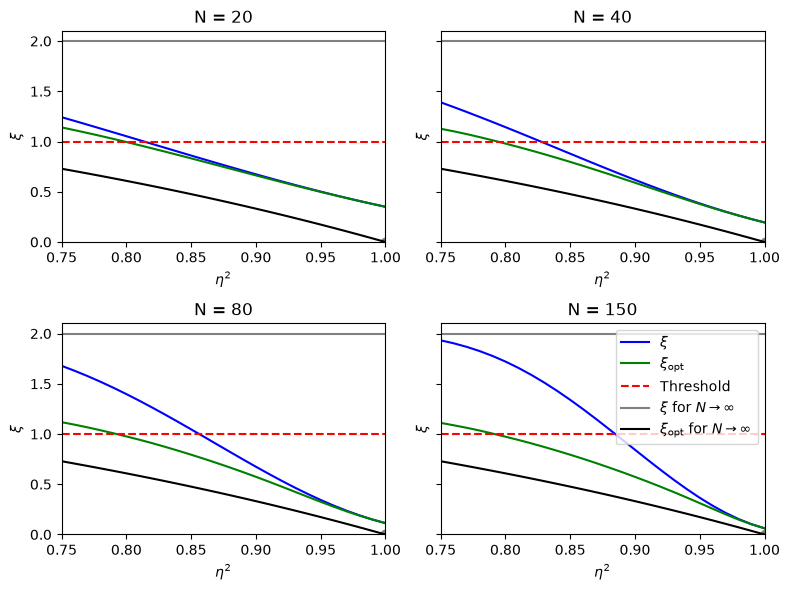

In [17]:
#gkp squeezing
Nspace = np.array([20,40,80,150])
eta = np.load(f'results/hex/eta.npy')
fq = np.sqrt(np.pi/8)*(3**(1/4) + 3**(-1/4))
fp = np.sqrt(np.pi/8)*(3**(1/4) - 3**(-1/4))
f = (2-2*np.exp(-np.abs(fq+1j*fp)**2*(1-eta)))
        
def load_dataset (dim):
    load1 = np.load(f'results/hex/gkp_sq_lossy_{dim}.npy')
    load2 = np.load(f'results/hex/gkp_sq_opt_{dim}.npy')
    return load1,load2

fq_format = "{:.2f}".format(fq)
fp_format = "{:.2f}".format(fp)

fig0, ax0 = plt.subplots(2,2,figsize=(8,6),sharey = True )
for i,dim in enumerate(Nspace):
    row = i // 2
    col = i  % 2
    ksi1,ksi2 = load_dataset(dim)
    ax0[row,col].plot(eta,ksi1,label = r'$\xi$', color = 'blue')
    ax0[row,col].plot(eta,ksi2,label = r'$\xi_{\text{opt}}$',color = 'green')
    ax0[row,col].axhline(y = 1, label = 'Threshold',color="red", linestyle = '--')
    ax0[row,col].set(xlabel = r'$\eta^2$',ylabel=r'$\xi$',title = fr'N = {dim}')
    ax0[row,col].set_xlim(0.75,1.0)
    ax0[row,col].set_ylim(0.0,2.1)
    ax0[row,col].axhline(y = 2,color = 'gray',label = r'$\xi$ for $N \rightarrow \infty$')
    ax0[row,col].plot(eta,f,color = 'black',label = r'$\xi_{\text{opt}}$ for $N \rightarrow \infty$')
    ax0[row,col].scatter(1,0,color = 'gray',marker='o')


ax0[1,1].legend()
plt.tight_layout()
plt.show()
fig0.savefig("results/figs/optimized_hex.svg")


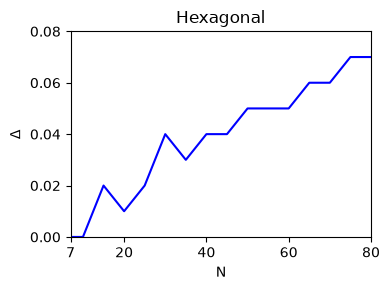

In [12]:
Nspace = np.load('results/hex/Nspace.npy')
eta = np.load('results/hex/eta.npy')

def load_dataset (dim):
    load1 = np.load(f'results/hex/gkp_sq_lossy_{dim}.npy')
    load2 = np.load(f'results/hex/gkp_sq_opt_{dim}.npy')
    return load1,load2

def closest_to_1(threshold,data):
    idx = min(range(len(data)), key=lambda i: abs(data[i] - threshold))
    value = data[idx]
    return value,idx

def diff_threshold(eta1,eta2):
    diff = np.abs(eta2-eta1)
    return diff

threshold = 1

improvement = []
for i,dim in enumerate(Nspace):
    load1,load2 = load_dataset(dim)
    value1,idx1 = closest_to_1(threshold,load1)
    value2,idx2 = closest_to_1(threshold,load2)
    eta1 = eta[idx1]
    eta2 = eta[idx2]
    diff = diff_threshold(eta1,eta2)
    improvement.append(diff)

fig0, ax0 = plt.subplots(figsize=(4,3),sharey = True )
ax0.plot(Nspace,improvement,color = 'blue',label = '')
ax0.set(xlabel = r'N',ylabel=r'$\Delta$',title = fr'Hexagonal')
ax0.set_xlim(7,80)
ax0.set_ylim(0,0.08)
ax0.set_xticks([7, 20, 40, 60, 80])
plt.tight_layout()
plt.show()
fig0.savefig("results/figs/improvement-hex.svg")

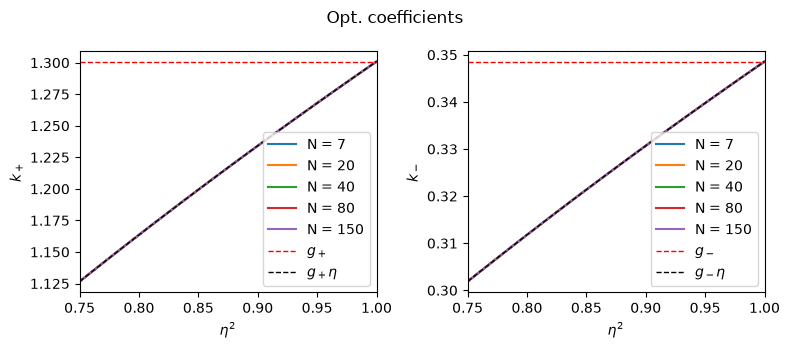

In [16]:
Nspace = np.array([7,20,40,80,150])
eta = np.load('results/hex/eta.npy')
fq = np.sqrt(np.pi/8)*(3**(1/4) + 3**(-1/4))
fp = np.sqrt(np.pi/8)*(3**(1/4) - 3**(-1/4))


def load_dataset (dim):
    load1 = np.load(f'results/hex/coef_opt_k1_{dim}.npy')
    load2 = np.load(f'results/hex/coef_opt_k2_{dim}.npy')
    return load1,load2

fq_format = "{:.2f}".format(fq)
fp_format = "{:.2f}".format(fp)

fig0, ax0 = plt.subplots(1,2,figsize=(8,3.5))
for i,dim in enumerate(Nspace):
    coef1,coef2 = load_dataset(dim)
    ax0[0].plot(eta,coef1, label = f'N = {dim}')
    ax0[1].plot(eta,coef2, label = f'N = {dim}')

ax0[0].axhline(y = fq, label = r'$g_+$',color="red", linestyle = '--',linewidth = 1)
ax0[1].axhline(y = fp, label = r'$g_-$',color="red", linestyle = '--',linewidth = 1)

ax0[0].set(xlabel = r'$\eta^2$',ylabel=r'$k_+$',title = fr'')
ax0[1].set(xlabel = r'$\eta^2$',ylabel=r'$k_-$',title = fr'')

ax0[0].set_xlim(0.75,1.0)
ax0[1].set_xlim(0.75,1.0)
f1 = fq*np.sqrt(eta)
f2 = fp*np.sqrt(eta)
ax0[0].plot(eta,f1,color = 'black', label= r'$g_+ \eta$',linestyle = '--',linewidth = 1)
ax0[1].plot(eta,f2,color = 'black', label= r'$g_- \eta$',linestyle = '--',linewidth = 1)
fig0.suptitle('Opt. coefficients')

ax0[0].legend()
ax0[1].legend()
plt.tight_layout()
plt.show()
fig0.savefig("results/figs/optimized_coef_hex.svg")
